# Baseline LSTM Encoder Notebook (toy-data)
**Goal:** prototype LSTM encoder pipeline (72h window @ 15-min resolution) using synthetic PV-like + weather data.  
- Validate windowing, dataset/dataloader, model, training loop, metrics, saving encoder outputs.  
- Document decisions and links to references: Hochreiter & Schmidhuber (1997), Colah LSTM blog, PyTorch `nn.LSTM` docs.


## Setup and Env check
Imports, random seed, device (GPU/CPU), reproductbility setup


In [4]:
# Setup & Imports
import os
import math
import time
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# An optional tqdm for progress bars (Helping the visuals of running)
try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x: x
    
# Reproducibility
# Setting a seed (Random Seed) ensures that if you run your code twice with the same inputs and model configuration, you get the exact same results.
RSEED = 42
random.seed(RSEED)
np.random.seed(RSEED)
torch.manual_seed(RSEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RSEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )
print("Device:", device)
# Missing: model.to(device) :: Check it before implementation



Device: cpu


## Notebook objectives & references
- Prototype LSTM encoder endpoint using synthetic data (so we can later plug real data).
- References to read (copy into your thesis notes):
  - Hochreiter & Schmidhuber, "Long Short-Term Memory" (1997).
  - Christopher Olah, "Understanding LSTMs" (blog) — intuitive gate explanation.
  - PyTorch docs: https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html


### Synthetic dataset
Create synthetic PV-like time series with:
- diurnal sine pattern (daily),
- slow seasonal trend,
- stochastic clouds/noise,
- some weather channels (temp, cloud_index).
This gives realistic shape to test windowing & model.
- This is done as there is no dataset available yet, and once real data is found, this can be completely omitted


In [6]:
def make_synthetic_pv(start_date="2024-01-01", hours=24*90, freq_minutes=15):
    """
    Create synthetic PV + weather time series.
    - hours: number of hours to simulate (default: 90 days -> 2160 hours)
    - freq_minutes: 15 -> 4 samples per hour
    """
    periods = int(hours * 60 / freq_minutes)
    idx = pd.date_range(start=start_date, periods=periods, freq=f"{freq_minutes}min")
    df = pd.DataFrame(index=idx)

    # Time features
    t = np.arange(periods)
    day_of_year = df.index.dayofyear.values
    hour = df.index.hour + df.index.minute / 60.0
    
    # Diurnal irradiance-like signal (sunrise-sunset)
    diurnal = np.clip(np.sin((hour - 6) / 24 * 2 * np.pi), 0, None)  # shifted sine, nights = 0
    # Seasonal amplitude (over the whole period)
    seasonal = 0.5 + 0.5 * np.sin(2*np.pi * (day_of_year / 365.0))
    # Cloud events: occasional drops (random)
    clouds = (np.random.rand(periods) * 0.6) * (np.random.rand(periods) < 0.05).astype(float)
    clouds = np.convolve(clouds, np.ones(12)/12, mode='same')  # smooth bursts

    # Weather channels
    temp = 10 + 10 * seasonal + 3*np.sin(2*np.pi * (hour/24)) + np.random.randn(periods)*0.5
    cloud_index = np.clip(0.2 + 0.7*clouds + 0.2*np.random.rand(periods), 0, 1)

    # PV raw (normalized 0..1), then scale to capacity (e.g., 1.0)
    pv_norm = diurnal * seasonal * (1 - cloud_index) + np.random.randn(periods)*0.01
    pv_norm = np.clip(pv_norm, 0, None)

    df['pv'] = pv_norm
    df['temp'] = temp
    df['cloud_index'] = cloud_index
    # Add a simple PVLib-like ideal clear-sky feature (proxy)
    df['ghi_clear'] = diurnal * seasonal

    return df

# create toy dataset
df = make_synthetic_pv(hours=24*40, freq_minutes=15)  # ~40 days so runs fast
df.head(), df.shape


(                           pv       temp  cloud_index  ghi_clear
 2024-01-01 00:00:00  0.001449  15.483280     0.308091        0.0
 2024-01-01 00:15:00  0.000000  14.300780     0.284688        0.0
 2024-01-01 00:30:00  0.000000  15.582931     0.334600        0.0
 2024-01-01 00:45:00  0.000873  15.697577     0.283144        0.0
 2024-01-01 01:00:00  0.000000  15.969064     0.364274        0.0,
 (3840, 4))

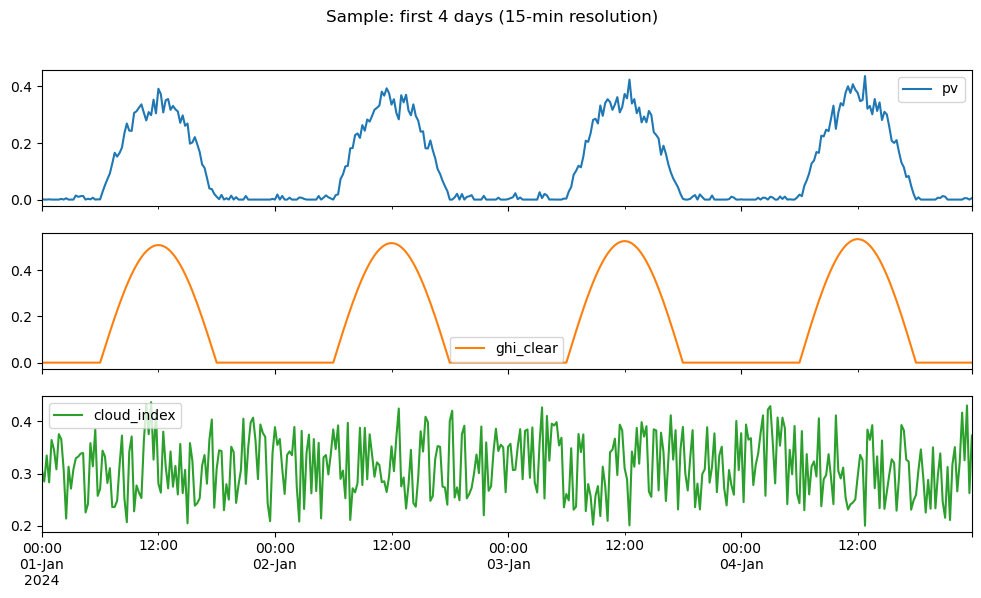

In [15]:
#Visualization of the above
df[['pv','ghi_clear','cloud_index']].iloc[:4*24*4].plot(subplots=True, figsize=(12,6))
plt.suptitle("Sample: first 4 days (15-min resolution)")
plt.show()


### Preprocessing
- Split into train/val/test by time (do NOT shuffle).
- Fit scalers only on training set to avoid leakage.
- Define helper to create rolling windows.


In [8]:
# Time split (80/10/10)
n = len(df)
train_end = int(0.8*n)
val_end = int(0.9*n)

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

FEATURES = ['pv','temp','cloud_index','ghi_clear']   # keep order consistent
TARGET = 'pv'  # for baseline

# Fit scaler on train features
scaler = StandardScaler()
scaler.fit(df_train[FEATURES])

def scale_df(df_):
    arr = scaler.transform(df_[FEATURES])
    scaled = pd.DataFrame(arr, index=df_.index, columns=FEATURES)
    return scaled

df_train_s = scale_df(df_train)
df_val_s   = scale_df(df_val)
df_test_s  = scale_df(df_test)

# Visual check
df_train_s.head()


,pv,temp,cloud_index,ghi_clear
2024-01-01 00:00:00,-0.821752,-0.389020,-0.032251,-0.815434
2024-01-01 00:15:00,-0.830257,-0.901253,-0.428416,-0.815434
2024-01-01 00:30:00,-0.830257,-0.345854,0.416490,-0.815434
2024-01-01 00:45:00,-0.825133,-0.296192,-0.454541,-0.815434
2024-01-01 01:00:00,-0.830257,-0.178589,0.918804,-0.815434


### Windowing and PyTorch Dataset
Create (X, y) pairs using sliding windows.
- seq_len: number of past timesteps (72h -> 288 for 15-min)
- horizon: timesteps ahead to predict (e.g., 1 step -> next 15min; or more)
We'll implement a Dataset class returning tensors shaped (seq_len, n_features).


In [9]:
class TimeSeriesWindowDataset(Dataset):
    def __init__(self, df_scaled, seq_len=288, horizon=1, features=FEATURES, target=TARGET):
        self.data = df_scaled.values.astype(np.float32)
        self.seq_len = seq_len
        self.horizon = horizon
        self.features = features
        self.target_index = features.index(target)
        self.n_samples = len(self.data) - seq_len - horizon + 1

    def __len__(self):
        return max(0, self.n_samples)

    def __getitem__(self, idx):
        start = idx
        end = idx + self.seq_len
        x = self.data[start:end, :]  # (seq_len, n_features)
        y = self.data[end + self.horizon - 1, self.target_index]  # scalar
        return torch.from_numpy(x), torch.tensor([y], dtype=torch.float32)

# Example shapes
SEQ_LEN = 288  # 72h at 15-min resolution
HORIZON = 1    # next timestep
train_ds = TimeSeriesWindowDataset(df_train_s, seq_len=SEQ_LEN, horizon=HORIZON)
val_ds   = TimeSeriesWindowDataset(df_val_s, seq_len=SEQ_LEN, horizon=HORIZON)
test_ds  = TimeSeriesWindowDataset(df_test_s, seq_len=SEQ_LEN, horizon=HORIZON)

print("train samples:", len(train_ds), "val:", len(val_ds), "test:", len(test_ds))


train samples: 2784 val: 96 test: 96


### DataLoader quick check
Check a single batch shape and sample values to confirm layout (batch, seq_len, features).


In [10]:
bs = 16
train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
xb, yb = next(iter(train_loader))
print("xb shape:", xb.shape)  # (batch, seq_len, features)
print("yb shape:", yb.shape)


xb shape: torch.Size([16, 288, 4])
yb shape: torch.Size([16, 1])


### LSTM Forecaster class
- We'll create a class that returns both: (a) prediction value, (b) the encoding vector (last hidden state).
- Save the encoding for later feeding into TFT.


In [11]:
class LSTMEncoderPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2, output_dim=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        out, (h_n, c_n) = self.lstm(x)  # out=(batch,seq,hidden), h_n=(num_layers,batch,hidden)
        last_hidden = h_n[-1]           # take last layer's hidden state -> (batch, hidden)
        prediction = self.fc(last_hidden)  # (batch, output_dim)
        return prediction, last_hidden

# Instantiate and move to device
model = LSTMEncoderPredictor(input_dim=len(FEATURES), hidden_dim=64, num_layers=2).to(device)
print(model)


LSTMEncoderPredictor(
  (lstm): LSTM(4, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


### Training loop & validation helpers
We include:
- MSE loss
- Optimizer (Adam)
- Validation function to compute RMSE / R2
- Simple early stopping


In [12]:
def evaluate(model, loader, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred, _ = model(xb)
            preds.append(pred.cpu().numpy())
            trues.append(yb.cpu().numpy())
    preds = np.vstack(preds).squeeze()
    trues = np.vstack(trues).squeeze()
    rmse = np.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds)
    return rmse, r2, preds, trues

# training loop
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, device=device, patience=5):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    criterion = nn.MSELoss()
    best_val = float('inf')
    best_state = None
    wait = 0

    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            pred, _ = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_rmse, val_r2, _, _ = evaluate(model, val_loader, device)
        print(f"Epoch {epoch:03d} | train_loss: {train_loss:.6f} | val_rmse: {val_rmse:.6f} | val_r2: {val_r2:.4f}")

        # Early stopping on val_rmse
        if val_rmse < best_val:
            best_val = val_rmse
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping.")
                break

    # load best
    if best_state is not None:
        model.load_state_dict(best_state)
    return model

# Build loaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

# Train (short epochs for notebook)
model = train_model(model, train_loader, val_loader, epochs=20, lr=1e-3, device=device, patience=5)


Epoch 001 | train_loss: 0.215430 | val_rmse: 0.308694 | val_r2: 0.9386
Epoch 002 | train_loss: 0.034922 | val_rmse: 0.252391 | val_r2: 0.9590
Epoch 003 | train_loss: 0.028545 | val_rmse: 0.215618 | val_r2: 0.9700
Epoch 004 | train_loss: 0.023867 | val_rmse: 0.208557 | val_r2: 0.9720
Epoch 005 | train_loss: 0.023186 | val_rmse: 0.200846 | val_r2: 0.9740
Epoch 006 | train_loss: 0.022726 | val_rmse: 0.199930 | val_r2: 0.9742
Epoch 007 | train_loss: 0.020813 | val_rmse: 0.192969 | val_r2: 0.9760
Epoch 008 | train_loss: 0.020942 | val_rmse: 0.197400 | val_r2: 0.9749
Epoch 009 | train_loss: 0.020167 | val_rmse: 0.196223 | val_r2: 0.9752
Epoch 010 | train_loss: 0.019899 | val_rmse: 0.202222 | val_r2: 0.9736
Epoch 011 | train_loss: 0.019829 | val_rmse: 0.181788 | val_r2: 0.9787
Epoch 012 | train_loss: 0.019197 | val_rmse: 0.204506 | val_r2: 0.9730
Epoch 013 | train_loss: 0.019661 | val_rmse: 0.191205 | val_r2: 0.9764
Epoch 014 | train_loss: 0.019014 | val_rmse: 0.185518 | val_r2: 0.9778
Epoch 

### Final evaluation on test set and result plots
Compute RMSE/R2 and plot true vs predicted for a portion of the series.


Test RMSE: 0.19810817680174053  R2: 0.9757502675056458


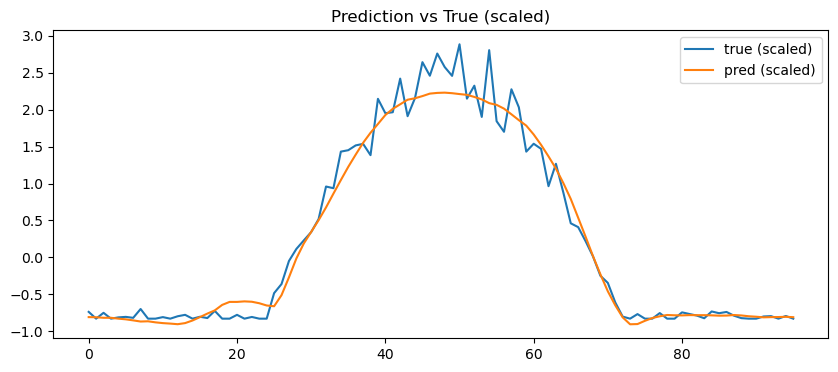

In [13]:
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
test_rmse, test_r2, preds_test, trues_test = evaluate(model, test_loader, device)
print("Test RMSE:", test_rmse, " R2:", test_r2)

# Plot a slice (unscaled axes are in standardized units); for visual checks this is ok:
plt.figure(figsize=(10,4))
plt.plot(trues_test[:500], label='true (scaled)')
plt.plot(preds_test[:500], label='pred (scaled)')
plt.legend()
plt.title("Prediction vs True (scaled)")
plt.show()


### Save LSTM encoding vectors for later TFT input
We'll run the encoder over the entire dataset to get last_hidden vectors per sample and save as CSV.


In [14]:
def extract_encodings(model, dataset, batch_size=64, device=device):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()
    encs = []
    idxs = []
    with torch.no_grad():
        for i, (xb, yb) in enumerate(loader):
            xb = xb.to(device)
            _, last_hidden = model(xb)
            encs.append(last_hidden.cpu().numpy())
    encs = np.vstack(encs)  # shape (n_samples, hidden_dim)
    return encs

encodings_train = extract_encodings(model, train_ds)
encodings_val   = extract_encodings(model, val_ds)
encodings_test  = extract_encodings(model, test_ds)

# Save to disk
out_dir = Path("experiments/lstm/encodings")
out_dir.mkdir(parents=True, exist_ok=True)
pd.DataFrame(encodings_train).to_csv(out_dir/"train_encodings.csv", index=False)
pd.DataFrame(encodings_val).to_csv(out_dir/"val_encodings.csv", index=False)
pd.DataFrame(encodings_test).to_csv(out_dir/"test_encodings.csv", index=False)
print("Saved encoding files to", out_dir)


Saved encoding files to experiments/lstm/encodings


### Replacing synthetic data with real PV + weather
When you have real data, replace the synthetic generation cell with:
1. Load raw CSV/NetCDF (or API fetched) into a single DataFrame `df` indexed by timestamp.
2. Ensure the same timezone & regular frequency (use `.resample()` / `.interpolate()` for gaps).
3. Use the `FEATURES` list to select/construct features (pv, temp, ghi, cloud_index, pvlib_clear, etc).
4. Fit scalers on train split only and call `scale_df()` function to create `df_train_s`, `df_val_s`, `df_test_s`.
5. Adjust `seq_len` (`SEQ_LEN`) and `HORIZON` to match your decision (72h -> 288).
6. Recreate datasets with `TimeSeriesWindowDataset`.
7. Re-run the training cells.


### Housekeeping & next steps
- Commit this notebook and the scripts used to generate it. Example commit message:
  `chore(lstm): add baseline LSTM notebook with synthetic data & encoding export`
- Next steps:
  1. Replace dataset with real data (Fraunhofer / open dataset).
  2. Run small-sample tests and verify performance.
  3. Save model & encodings and prepare TFT input pipeline.
  4. Move stable model code to `src/models/lstm_model.py` and training script to `src/training/train_lstm.py`.
